# Estimating PSDs

This notebook should be run to get estimated PSDs from the LDC sangria dataset, as well as saving/smoothing the sangria noise model which contains unresolvable galactic binaries

In [1]:
import numpy as np
from copy import deepcopy

from pycbc.types import TimeSeries, FrequencySeries
from pycbc.psd import interpolate, from_txt

import ldc.io.hdf5 as hdfio
import ldc.lisa.noise.noise as ldc_noise

from scipy.signal import windows

from matplotlib import pyplot as plt
plt.style.use('../paper.mplstyle')

/mnt/lustre2/shared_conda/envs/garethcd/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
/mnt/lustre2/shared_conda/envs/garethcd/env_lisa_premerger_sangria/lib/python3.11/site-packages/lisaconstants/compat/astropy.py:252: UserWarning: The following constants differ between lisaconstants and the version of astropy you have installed: VACUUM_PERMEABILITY. The recommended version 

## Estimate PSDs from the data

The heavy work - loading the full 3 GB time-domain dataset, running Welch PSD estimates over ~6.3 M samples per channel, and subtracting out every signal type to get a noise-only residual - lives in **`estimate_psds.py`** (run with `bash estimate_psds.sh`). It writes the estimated and smoothed PSDs out as `.txt` files.

This notebook no longer does that work (doing it here OOM-killed the kernel). It just loads the saved PSDs for a quick sanity check, and then plots them. For full plotting see **`plot_psds.ipynb`**.


In [2]:
duration = 365 * 86400
delta_t = 4
flen = int(duration / delta_t) // 2 + 1
delta_f = 1 / duration

A_psd = from_txt('A_sangria_hm_PSD.txt', flen, delta_f, delta_f, is_asd_file=False)
E_psd = from_txt('E_sangria_hm_PSD.txt', flen, delta_f, delta_f, is_asd_file=False)
T_psd = from_txt('T_sangria_hm_PSD.txt', flen, delta_f, delta_f, is_asd_file=False)

# The noise-only residual PSDs (data with every signal type removed).
residual_A_psd = from_txt('residual_A_sangria_hm_PSD.txt', flen, delta_f, delta_f, is_asd_file=False)
residual_E_psd = from_txt('residual_E_sangria_hm_PSD.txt', flen, delta_f, delta_f, is_asd_file=False)


Requested number of samples exceeds the highest available frequency in the input data, will use max available frequency instead. (requested 0.125000 Hz, available 0.100000 Hz)
/mnt/lustre2/shared_conda/envs/garethcd/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/psd/read.py:76: RuntimeWarning: divide by zero encountered in log
  slog = numpy.log(noise_data)
Requested number of samples exceeds the highest available frequency in the input data, will use max available frequency instead. (requested 0.125000 Hz, available 0.100000 Hz)
Requested number of samples exceeds the highest available frequency in the input data, will use max available frequency instead. (requested 0.125000 Hz, available 0.100000 Hz)
Requested number of samples exceeds the highest available frequency in the input data, will use max available frequency instead. (requested 0.125000 Hz, available 0.100000 Hz)
Requested number of samples exceeds the highest available frequency in the input data, will use m

In [ ]:
# Get the Sangria noise model with and without unresolvable galactic binaries
sangria_model_freqs = A_psd.sample_frequencies

# No-GB PSDs
sangria_model_ae_nogb = from_txt('model_AE_NOGB_PSD.txt', flen, delta_f, delta_f, is_asd_file=False)
sangria_model_t_nogb = from_txt('model_T_NOGB_PSD.txt', flen, delta_f, delta_f, is_asd_file=False)


sangria_model_ae_withgb = from_txt('model_AE_PSD.txt', flen, delta_f, delta_f, is_asd_file=False)
sangria_model_t_withgb = from_txt('model_T_PSD.txt', flen, delta_f, delta_f, is_asd_file=False)


Requested number of samples exceeds the highest available frequency in the input data, will use max available frequency instead. (requested 0.125000 Hz, available 0.100000 Hz)
Requested number of samples exceeds the highest available frequency in the input data, will use max available frequency instead. (requested 0.125000 Hz, available 0.100000 Hz)
Requested number of samples exceeds the highest available frequency in the input data, will use max available frequency instead. (requested 0.125000 Hz, available 0.100000 Hz)
Requested number of samples exceeds the highest available frequency in the input data, will use max available frequency instead. (requested 0.125000 Hz, available 0.100000 Hz)


Now lets go through and remove all signals from the data, this will give us an estimate of the noise which we can compare to the model we used in the zero latency filter paper

Lets quickly plot these so we can see what is happening.

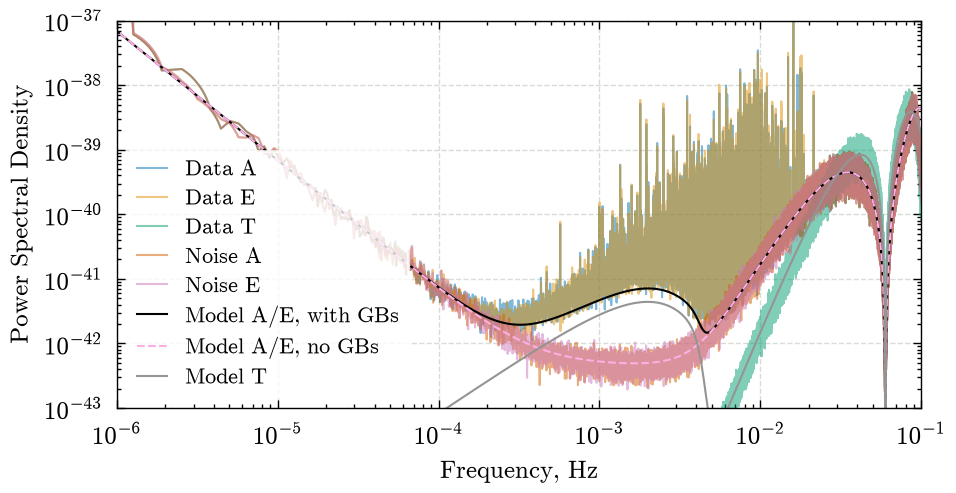

In [4]:
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
width = plt.rcParams["figure.figsize"][0] * 1.5
height = plt.rcParams["figure.figsize"][1] * 1.25
# Lets plot the PSDs to compare them:
fig, ax = plt.subplots(1, figsize=(width, height))

lines_to_plot = (
    (A_psd, 'Data A', cycle[0], '-', 0.5),
    (E_psd, 'Data E', cycle[1], '-', 0.5),
    (T_psd, 'Data T', cycle[2], '-', 0.5),
    (residual_A_psd, 'Noise A', cycle[3], '-', 0.5),
    (residual_E_psd, 'Noise E', cycle[4], '-', 0.5),
    (sangria_model_ae_withgb, 'Model A/E, with GBs', 'k', '-', 1),
    (sangria_model_ae_nogb, 'Model A/E, no GBs', cycle[6], '--', 1),
    (sangria_model_t_withgb, 'Model T', cycle[7], '-', 1),
)

for (psd, label, color, linestyle, alpha) in lines_to_plot:
    ax.loglog(
        psd.sample_frequencies,
        psd,
        label=label,
        color=color,
        linestyle=linestyle,
        alpha=alpha,
        rasterized=True
    )


ax.set_ylabel("Power Spectral Density")
ax.set_xlabel("Frequency, Hz")
ax.legend(loc='lower left')
ax.set_ylim([1e-43, 1e-37])
ax.set_xlim([1e-6, 1e-1])
ax.grid(zorder=-100)

Now, lets smooth out the dip at 0.06Hz. We did this in estimate_psds.py, but we will demonstrate the process here

[1102984 3067167]
0.034975393201420596 0.09725922754946727
[4.47578734e-40 4.39180769e-39]


(0.03, 0.12)

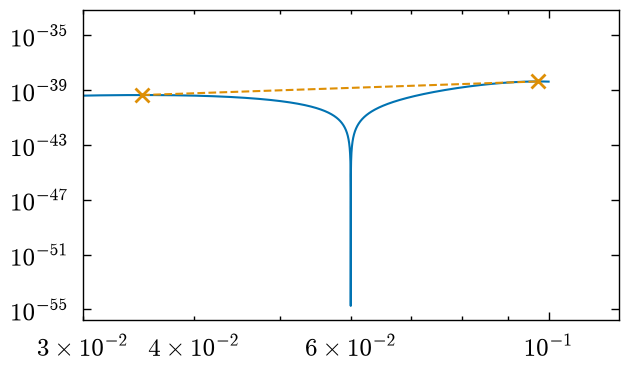

In [5]:
from scipy.signal import find_peaks

pks = find_peaks(
    np.where(
        np.logical_and(
            sangria_model_freqs > 0.01,
            sangria_model_freqs < 0.1
        ),
        sangria_model_ae_withgb,
        0
    )
)[0]
print(pks)

section_lower, section_upper = sangria_model_freqs[pks]
print(section_lower, section_upper)
print(sangria_model_ae_withgb[pks])

plt.loglog(sangria_model_freqs, sangria_model_ae_withgb)
plt.plot(sangria_model_freqs[pks], sangria_model_ae_withgb[pks], linestyle='--', marker='x')
plt.xlim(0.03, 0.12)

Peaks at 0.0350 and 0.097, so lets use 0.03 and 0.9 just as they are rounder numbers

We use a Hann window to smoothly go transition between the data and the line, so now we plot the 

In [ ]:
# smoothed versions of the PSDs
A_psd_smoothed = from_txt('A_sangria_hm_SMOOTHED_PSD.txt', flen, delta_f, delta_f, is_asd_file=False)
E_psd_smoothed = from_txt('E_sangria_hm_SMOOTHED_PSD.txt', flen, delta_f, delta_f, is_asd_file=False)

model_ae_smoothed = from_txt('model_AE_SMOOTHED_PSD.txt', flen, delta_f, delta_f, is_asd_file=False)

Requested number of samples exceeds the highest available frequency in the input data, will use max available frequency instead. (requested 0.125000 Hz, available 0.100000 Hz)
Requested number of samples exceeds the highest available frequency in the input data, will use max available frequency instead. (requested 0.125000 Hz, available 0.100000 Hz)
Requested number of samples exceeds the highest available frequency in the input data, will use max available frequency instead. (requested 0.125000 Hz, available 0.100000 Hz)


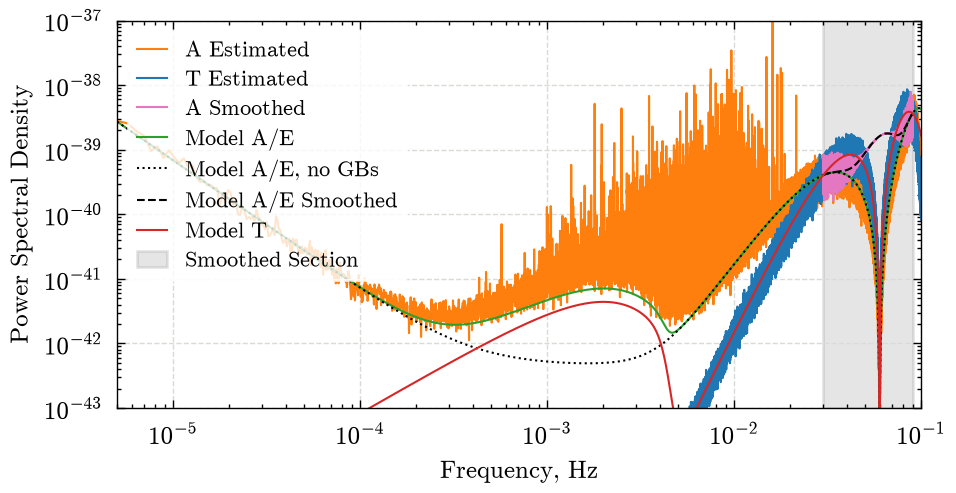

In [7]:
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
width = plt.rcParams["figure.figsize"][0] * 1.5
height = plt.rcParams["figure.figsize"][1] * 1.25
# Lets plot the PSDs to compare them:
fig, ax = plt.subplots(1, figsize=(width, height))

lines_to_plot = (
    (A_psd, 'A Estimated', 'tab:orange', '-', 1, None, None),
    (T_psd, 'T Estimated', 'tab:blue', '-', 1, None, None),
    (A_psd_smoothed, 'A Smoothed', 'tab:pink', '-', 1, 0.03, 0.09),
    (sangria_model_ae_withgb, 'Model A/E', 'tab:green', '-', 1, None, None),
    (sangria_model_ae_nogb, 'Model A/E, no GBs', 'k', ':', 1, None, None),
    (model_ae_smoothed, 'Model A/E Smoothed', 'k', '--', 1, 0.03, 0.09),
    (sangria_model_t_withgb, 'Model T', 'tab:red', '-', 1, None, None),
)

for (psd, label, color, linestyle, alpha, freqmin, freqmax) in lines_to_plot:
    if freqmin is not None:
        idx_min = np.argmin(abs(psd.sample_frequencies - freqmin))
    else:
        idx_min = None
    if freqmax is not None:
        idx_max = np.argmin(abs(psd.sample_frequencies - freqmax))
    else:
        idx_max = None
    ax.loglog(
        psd.sample_frequencies[idx_min:idx_max],
        psd[idx_min:idx_max],
        label=label,
        color=color,
        linestyle=linestyle,
        alpha=alpha,
        rasterized=True
    )

ax.axvspan(
    0.03, 0.09,
    color='gray', zorder=-100, label='Smoothed Section', alpha=0.2
)


ax.set_ylabel("Power Spectral Density")
ax.set_xlabel("Frequency, Hz")
ax.legend(loc='upper left')
ax.set_ylim([1e-43, 1e-37])
ax.set_xlim([5e-6, 1e-1])
ax.grid(zorder=-100)

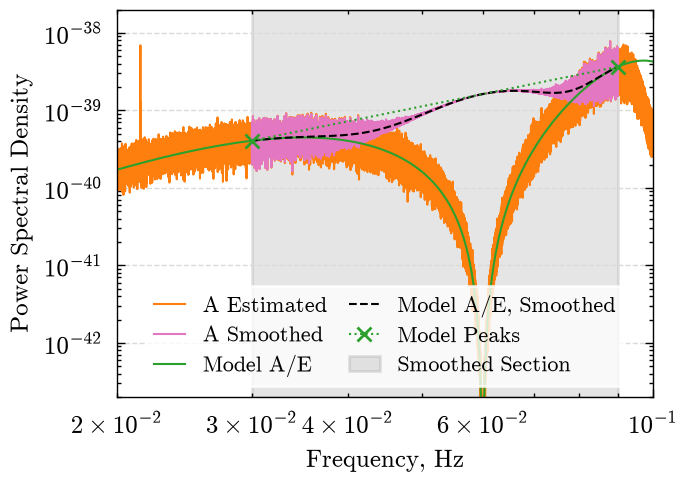

In [11]:
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
width = plt.rcParams["figure.figsize"][0]
height = plt.rcParams["figure.figsize"][1] * 1.25
# Lets plot the PSDs to compare them:
fig, ax = plt.subplots(1, figsize=(width, height))

lines_to_plot = (
    (A_psd, 'A Estimated', 'tab:orange', '-', 1, None, None),
    (A_psd_smoothed, 'A Smoothed', 'tab:pink', '-', 1, 0.03, 0.09),
    (sangria_model_ae_withgb, 'Model A/E', 'tab:green', '-', 1, None, None),
    (model_ae_smoothed, 'Model A/E, Smoothed', 'k', '--', 1, 0.03, 0.09),
)

for (psd, label, color, linestyle, alpha, freqmin, freqmax) in lines_to_plot:
    if freqmin is not None:
        idx_min = np.argmin(abs(psd.sample_frequencies - freqmin))
    else:
        idx_min = None
    if freqmax is not None:
        idx_max = np.argmin(abs(psd.sample_frequencies - freqmax))
    else:
        idx_max = None
    ax.loglog(
        psd.sample_frequencies[idx_min:idx_max],
        psd[idx_min:idx_max],
        label=label,
        color=color,
        linestyle=linestyle,
        alpha=alpha,
        rasterized=True
    )


scatter_freqs = [0.03, 0.09]
scatter_ys = [None, None]
for i, freq in enumerate(scatter_freqs):
    idx = np.argmin(abs(sangria_model_ae_withgb.sample_frequencies - freq))
    scatter_ys[i] = sangria_model_ae_withgb[idx]
ax.loglog(
    scatter_freqs, scatter_ys, color='tab:green', marker='x', linestyle=':', zorder=50, label='Model Peaks'
)

ax.axvspan(
    0.03, 0.09,
    color='gray', zorder=-100, label='Smoothed Section', alpha=0.2
)


ax.set_ylabel("Power Spectral Density")
ax.set_xlabel("Frequency, Hz")
ax.legend(loc='lower center', ncol=2)
ax.set_ylim([2e-43, 2e-38])
ax.set_xlim([2e-2, 1e-1])
ax.grid(zorder=-100)

fig.savefig('../paper/images/dataset/figure_2_smoothing_60mHz.png')